# 03 — Statistical Testing

Which predictors are associated with 30-day readmission?

- categorical: chi-square test of independence
- numeric: Welch t-test, or Mann-Whitney U when the feature is very skewed

We apply a Benjamini-Hochberg correction because several tests are run.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.multitest import multipletests

from src.config import PROCESSED_DIR, TARGET, FIGURES_DIR, TABLES_DIR

In [2]:
df = pd.read_csv(PROCESSED_DIR / 'cleaned.csv')
y = df[TARGET]
num = df.select_dtypes('number').drop(columns=[TARGET]).columns.tolist()
binary = [c for c in num if df[c].dropna().isin([0, 1]).all()]
num = [c for c in num if c not in binary]
cat = df.select_dtypes(exclude='number').columns.tolist() + binary
print('numeric:', num)
print('categorical:', cat)

numeric: ['age', 'bmi', 'bnp', 'sodium', 'creatinine', 'systolic_bp', 'heart_rate', 'adherence_score', 'distance_to_hospital_km']
categorical: ['gender', 'income_level', 'ace_inhibitor', 'beta_blocker', 'diuretic']


In [3]:
rows = []
for c in cat:
    table = pd.crosstab(df[c], y)
    chi2, p, dof, _ = stats.chi2_contingency(table)
    rows.append({'feature': c, 'chi2': chi2, 'dof': dof, 'p_raw': p})
chi = pd.DataFrame(rows)
chi['p_adj'] = multipletests(chi['p_raw'], method='fdr_bh')[1]
chi['significant'] = chi['p_adj'] < 0.05
chi = chi.sort_values('p_adj')
chi.to_csv(TABLES_DIR / 'tbl_categorical_vs_target.csv', index=False)
chi.round(4)

,feature,chi2,dof,p_raw,p_adj,significant
2,ace_inhibitor,25.6878,1,0.0000,0.0000,True
3,beta_blocker,21.5888,1,0.0000,0.0000,True
4,diuretic,0.6756,1,0.4111,0.6852,False
0,gender,0.0002,1,0.9876,0.9876,False
1,income_level,0.4509,2,0.7982,0.9876,False


In [4]:
rows = []
for c in num:
    a = df.loc[y == 1, c].dropna()
    b = df.loc[y == 0, c].dropna()
    if abs(stats.skew(df[c].dropna())) > 1:
        stat, p = stats.mannwhitneyu(a, b)
        test = 'mannwhitney'
    else:
        stat, p = stats.ttest_ind(a, b, equal_var=False)
        test = 'welch_t'
    rows.append({'feature': c, 'test': test, 'mean_readmit': a.mean(),
                 'mean_no': b.mean(), 'stat': stat, 'p_raw': p})
numres = pd.DataFrame(rows)
numres['p_adj'] = multipletests(numres['p_raw'], method='fdr_bh')[1]
numres['significant'] = numres['p_adj'] < 0.05
numres = numres.sort_values('p_adj')
numres.to_csv(TABLES_DIR / 'tbl_numeric_vs_target.csv', index=False)
numres.round(4)

,feature,test,mean_readmit,mean_no,stat,p_raw,p_adj,significant
7,adherence_score,welch_t,0.6593,0.7274,-10.6833,0.0000,0.0000,True
2,bnp,welch_t,451.1305,374.9881,8.8598,0.0000,0.0000,True
0,age,welch_t,66.8752,64.1217,5.0237,0.0000,0.0000,True
8,distance_to_hospital_km,welch_t,26.5335,24.6071,3.6985,0.0002,0.0005,True
3,sodium,welch_t,137.8431,138.2624,-2.7354,0.0063,0.0113,True
4,creatinine,welch_t,1.2339,1.1900,2.4349,0.0150,0.0224,True
5,systolic_bp,welch_t,130.4384,128.9949,1.9393,0.0526,0.0676,False
1,bmi,welch_t,28.2904,28.0033,1.5466,0.1221,0.1373,False
6,heart_rate,welch_t,79.1792,79.5575,-0.6702,0.5028,0.5028,False


In [5]:
# 95% confidence interval for each numeric mean
rows = []
for c in num:
    x = df[c].dropna()
    se = x.std(ddof=1) / np.sqrt(len(x))
    lo, hi = stats.t.interval(0.95, len(x) - 1, loc=x.mean(), scale=se)
    rows.append({'feature': c, 'mean': x.mean(), 'ci_low': lo, 'ci_high': hi})
cis = pd.DataFrame(rows)
cis.to_csv(TABLES_DIR / 'tbl_mean_cis.csv', index=False)
cis.round(3)

,feature,mean,ci_low,ci_high
0,age,65.254,64.724,65.784
1,bmi,28.121,27.942,28.301
2,bnp,406.308,397.993,414.623
3,sodium,138.089,137.943,138.236
4,creatinine,1.208,1.191,1.226
5,systolic_bp,129.589,128.863,130.314
6,heart_rate,79.402,78.857,79.946
7,adherence_score,0.699,0.693,0.706
8,distance_to_hospital_km,25.400,24.893,25.906


In [6]:
# standardized residuals from the ace_inhibitor vs target table
table = pd.crosstab(df['ace_inhibitor'], y)
chi2, p, dof, expected = stats.chi2_contingency(table)
resid = (table - expected) / np.sqrt(expected)
resid.index = [f'ace={i}' for i in resid.index]
resid.columns = [f'readmit={c}' for c in resid.columns]
resid.to_csv(TABLES_DIR / 'tbl_std_residuals_ace.csv')
resid.round(3)

,readmit=0,readmit=1
ace=0,-2.365,2.829
ace=1,2.265,-2.709


,feature,OR,lo,hi
0,ace_inhibitor,0.684,0.591,0.792
1,beta_blocker,0.706,0.610,0.817
2,diuretic,1.066,0.922,1.233
3,gender_male,1.004,0.868,1.161


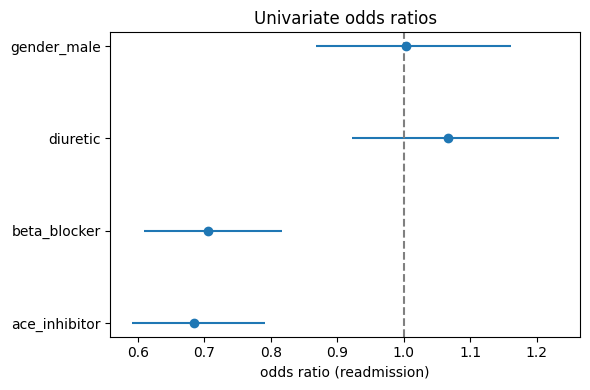

In [7]:
# univariate odds ratios for the binary predictors
ors = []
for c in ['ace_inhibitor', 'beta_blocker', 'diuretic']:
    m = sm.Logit(y, sm.add_constant(df[c])).fit(disp=0)
    lo, hi = np.exp(m.conf_int().loc[c])
    ors.append({'feature': c, 'OR': np.exp(m.params[c]), 'lo': lo, 'hi': hi})
g = (df['gender'] == 'Male').astype(int).rename('gender_male')
m = sm.Logit(y, sm.add_constant(g)).fit(disp=0)
lo, hi = np.exp(m.conf_int().loc['gender_male'])
ors.append({'feature': 'gender_male', 'OR': np.exp(m.params['gender_male']), 'lo': lo, 'hi': hi})
ors = pd.DataFrame(ors)
pos = np.arange(len(ors))
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(ors['OR'], pos, xerr=[ors['OR'] - ors['lo'], ors['hi'] - ors['OR']], fmt='o')
ax.axvline(1, color='grey', ls='--')
ax.set_yticks(pos)
ax.set_yticklabels(ors['feature'])
ax.set_xlabel('odds ratio (readmission)')
ax.set_title('Univariate odds ratios')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_odds_ratios.png', dpi=120)
ors.round(3)

observed diff: -0.0681 | p-value: 0.0


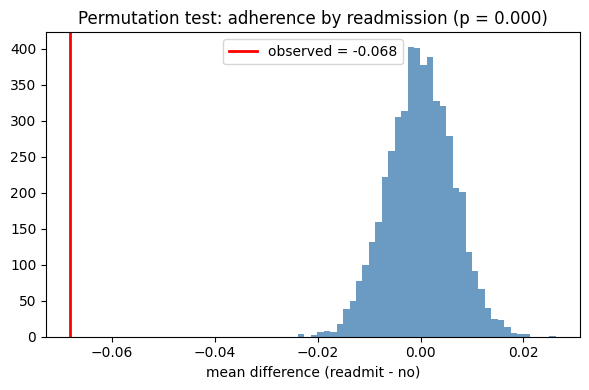

In [8]:
# permutation test: difference in mean adherence by readmission
obs = df.loc[y == 1, 'adherence_score'].mean() - df.loc[y == 0, 'adherence_score'].mean()
vals = df['adherence_score'].values
labels = y.values
rng = np.random.default_rng(0)
perm = np.array([
    (lambda p: vals[p == 1].mean() - vals[p == 0].mean())(rng.permutation(labels))
    for _ in range(5000)])
pval = np.mean(np.abs(perm) >= abs(obs))
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(perm, bins=40, color='steelblue', alpha=0.8)
ax.axvline(obs, color='red', lw=2, label=f'observed = {obs:.3f}')
ax.set_title(f'Permutation test: adherence by readmission (p = {pval:.3f})')
ax.set_xlabel('mean difference (readmit - no)')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_perm_adherence.png', dpi=120)
print('observed diff:', round(obs, 4), '| p-value:', round(pval, 4))